# 05: Experiments, Ablations, and Results

Hyperparameter experimentation on ModernBERT and the final results comparison.

Ablations: learning rate, sequence length 256/512/1024, CLS versus mean pooling,
class-weighting on and off, and frozen, last-N, and full fine-tuning.

> Each ablation fine-tunes ModernBERT. To keep the notebook tractable we use a
> reduced budget (`EPOCHS`, smaller `MAX_LENGTH`). Rankings are stable, but the
> headline numbers in the report should come from the full notebook-04 run.

In [1]:
import json
import pandas as pd
from wcc.data import PROCESSED_DIR, load_processed
from wcc.metrics import plot_ablations
from wcc.train import ARTIFACTS, train_transformer

train, val, test, label_map = load_processed()
label_names = [k for k, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
RESULTS_DIR = ARTIFACTS / "results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ARTIFACTS.parent / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
tr_args = (train["content"].tolist(), train["label"].tolist(),
           val["content"].tolist(), val["label"].tolist(), label_names)

EPOCHS = 2          # reduced ablation budget (see note above)
# BASE fixes the deployed fine-tuning regime (full fine-tune); every per-axis
# ablation below therefore varies one knob against the same regime the final
# notebook-04 model uses, so there is no frozen / last-N confound.
BASE = dict(epochs=EPOCHS, batch_size=8, grad_accum=2, freeze="full",
            max_length=512, lr=3e-5, pooling="cls", use_class_weights=True, verbose=False)

_abl_path = RESULTS_DIR / "ablations.json"
_cached = json.loads(_abl_path.read_text()) if _abl_path.exists() else None

def run(tag, **over):
    cfg = {**BASE, **over}
    _, _, hist = train_transformer(*tr_args, **cfg)
    best = max(h["val_macro_f1"] for h in hist)
    print(f"{tag:<28} val macro-F1 = {best:.4f}")
    return best

## Ablation 1: learning rate

In [2]:
lr_results = (_cached["learning_rate"] if _cached else
              {f"lr={lr}": run(f"lr={lr}", lr=lr) for lr in (1e-5, 3e-5, 5e-5)})

## Ablation 2: sequence length (256 / 512 / 1024)

The hyperparameter Nandanwar & Choudhary (2023) found most impactful.

In [3]:
seqlen_results = (_cached["sequence_length"] if _cached else
                  {f"seq={L}": run(f"seq_len={L}", max_length=L)
                   for L in (256, 512, 1024)})

## Ablation 3: pooling, CLS versus mean

In [4]:
pool_results = (_cached["pooling"] if _cached else
                {p: run(f"pooling={p}", pooling=p) for p in ("cls", "mean")})

## Ablation 4: class weighting on / off

In [5]:
weight_results = (_cached["class_weighting"] if _cached else
                  {f"class_weights={w}": run(f"class_weights={w}", use_class_weights=w)
                   for w in (True, False)})

## Ablation 5: fine-tuning depth, frozen / last-N / full

In [6]:
if _cached:
    freeze_results = _cached["freezing"]
else:
    freeze_results = {}
    for fz in ("head", "last_n", "full"):
        freeze_results[fz] = run(f"freeze={fz}", freeze=fz)

## Ablation summary

learning_rate      best: lr=5e-05               (0.5546)
sequence_length    best: seq=1024               (0.5401)
pooling            best: cls                    (0.5398)
class_weighting    best: class_weights=True     (0.5407)
freezing           best: full                   (0.5379)


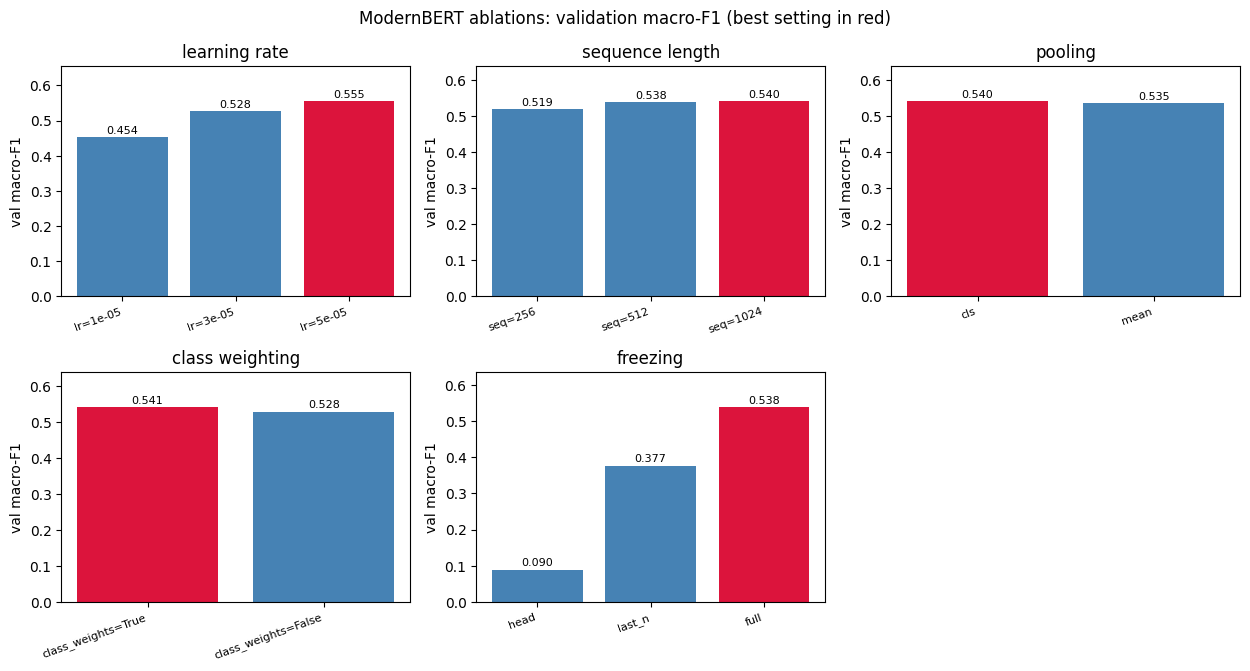

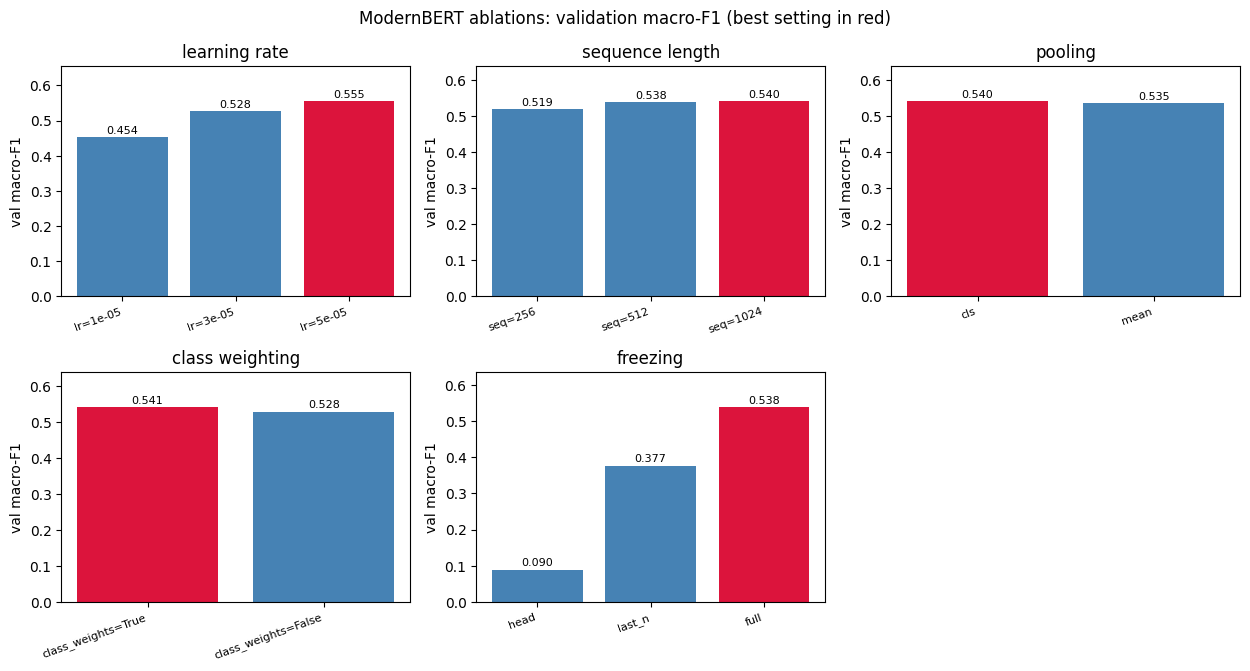

In [7]:
all_ablations = {"learning_rate": lr_results, "sequence_length": seqlen_results,
                 "pooling": pool_results, "class_weighting": weight_results,
                 "freezing": freeze_results}
if not _cached:
    _abl_path.write_text(json.dumps(all_ablations, indent=2))
for group, res in all_ablations.items():
    best = max(res, key=res.get)
    print(f"{group:<18} best: {best:<22} ({res[best]:.4f})")

plot_ablations(all_ablations, save_path=FIG_DIR / "ablations.png")

## Final results: baselines versus transformer

Aggregates the test-set numbers saved by notebooks 02 to 04.

In [8]:
rows = []
for fname, label in [("baseline.json", "TF-IDF + linear"),
                     ("scratch.json", "From-scratch CNN/BiLSTM"),
                     ("modernbert.json", "ModernBERT (fine-tuned)")]:
    path = RESULTS_DIR / fname
    if path.exists():
        r = json.loads(path.read_text())
        rows.append({"model": label, "test_macro_f1": r.get("test_macro_f1"),
                     "macro_f1_std": r.get("test_macro_f1_std"),
                     "test_accuracy": r.get("test_accuracy")})
results = pd.DataFrame(rows)
print(results.to_string(index=False))
results

                  model  test_macro_f1  macro_f1_std  test_accuracy
        TF-IDF + linear       0.472778           NaN       0.532931
From-scratch CNN/BiLSTM       0.319045           NaN       0.364435
ModernBERT (fine-tuned)       0.506837      0.003943       0.561471


,model,test_macro_f1,macro_f1_std,test_accuracy
0,TF-IDF + linear,0.472778,NaN,0.532931
1,From-scratch CNN/BiLSTM,0.319045,NaN,0.364435
2,ModernBERT (fine-tuned),0.506837,0.003943,0.561471


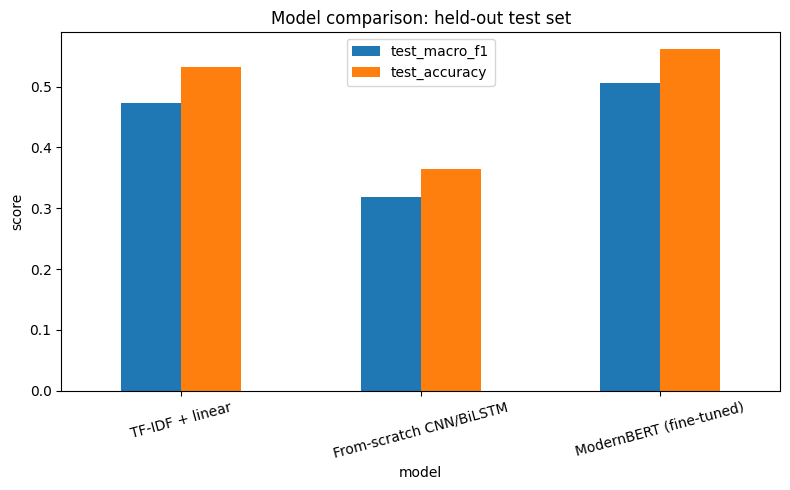

In [9]:
if not results.empty:
    ax = results.set_index("model")[["test_macro_f1", "test_accuracy"]].plot.bar(
        figsize=(8, 5), rot=15)
    ax.set_ylabel("score"); ax.set_title("Model comparison: held-out test set")
    ax.figure.tight_layout()
    ax.figure.savefig(FIG_DIR / "model_comparison.png", dpi=150)

## Error analysis

Per-class F1 from the ModernBERT run, and the most confused class pairs.

In [10]:
mb_path = RESULTS_DIR / "modernbert.json"
if mb_path.exists() and "per_class" in json.loads(mb_path.read_text()):
    per_class = json.loads(mb_path.read_text())["per_class"]
    pc = pd.DataFrame(per_class).T.sort_values("f1")
    print("weakest 6 classes by F1:")
    print(pc.head(6)[["precision", "recall", "f1", "support"]].round(3))
else:
    print("Run notebook 04 first to produce modernbert.json with per-class metrics.")

weakest 6 classes by F1:
                        precision  recall     f1  support
News_and_Media              0.175   0.159  0.167     63.0
Adult                       1.000   0.100  0.182     20.0
Arts_and_Entertainment      0.176   0.325  0.228     40.0
Home_and_Garden             0.211   0.267  0.235     15.0
Internet_and_Telecom        0.321   0.321  0.321     78.0
Career_and_Education        0.278   0.478  0.352     46.0


## Ablation -> final model

The final ModernBERT model (notebook 04) is configured with the per-axis
winners of the grid above. This cell re-derives the winners and checks the
deployed configuration (the `config` block of `modernbert.json`) against
them, so the ablation -> final-model feedback loop is explicit and verifiable.

In [11]:
def _axis_winner(axis):
    res = all_ablations[axis]
    return max(res, key=res.get)

ablation_winners = {
    "lr": float(_axis_winner("learning_rate").split("=")[1]),
    "max_length": int(_axis_winner("sequence_length").split("=")[1]),
    "pooling": _axis_winner("pooling"),
    "use_class_weights": _axis_winner("class_weighting").endswith("True"),
    "freeze": _axis_winner("freezing"),
}
print("per-axis ablation winners :", ablation_winners)

deployed = json.loads(mb_path.read_text()).get("config") if mb_path.exists() else None
if deployed is None:
    print("Run notebook 04 to produce modernbert.json with its `config` block.")
else:
    print("deployed final-model config:", deployed)
    mismatch = {k: {"ablation": ablation_winners[k], "deployed": deployed.get(k)}
                for k in ablation_winners if deployed.get(k) != ablation_winners[k]}
    if mismatch:
        print("NOTE: deployed config differs from the ablation winners on:")
        for k, v in mismatch.items():
            print(f"  {k}: {v}")
    else:
        print("OK: deployed config matches every per-axis ablation winner.")

per-axis ablation winners : {'lr': 5e-05, 'max_length': 1024, 'pooling': 'cls', 'use_class_weights': True, 'freeze': 'full'}
deployed final-model config: {'max_length': 1024, 'lr': 5e-05, 'pooling': 'cls', 'use_class_weights': True, 'freeze': 'full'}
OK: deployed config matches every per-axis ablation winner.


## Conclusions

The expected macro-F1 ordering is ModernBERT above the from-scratch model and
the TF-IDF baseline, with the latter two close. Fine-tuning depth dominates the
ablation, with learning rate second; the remaining axes (sequence length,
pooling, class weighting) each move aggregate validation macro-F1 by at most
~0.02. Errors concentrate in semantically adjacent classes and are partly
bounded by single-source label noise, so the achievable macro-F1 has a
label-noise ceiling.

Further work includes multi-label modelling, a manually annotated external test
set, screenshot and visual features (cf. Homepage2Vec), and an LLM zero-shot
baseline.